# Multilayer Perceptron Example

This notebook presents a **Multilayer Perceptron (MLP)** classifier
implemented from scratch with the custom `MultilayerPerceptron` class
from the `rice_ml` package.

The notebook uses the same ionosphere dataset as the original version,
but the explanations are rewritten in slightly different wording.

In this notebook, we will:

- review why a single-layer perceptron is limited
- introduce hidden layers and nonlinear activations
- train an MLP on a real binary classification dataset
- compare the MLP against a basic perceptron baseline


## Why Move Beyond a Single-Layer Perceptron?

A standard perceptron can only learn a **linear decision boundary**.
That works for simple problems, but it is often too restrictive for real
datasets.

For example, a single-layer perceptron struggles when:

- the classes are not linearly separable
- the relationship between predictors and the outcome is nonlinear
- useful patterns appear only through interactions among features

A Multilayer Perceptron improves on this by adding:

- one or more hidden layers
- nonlinear activation functions

These additions let the model represent much more flexible decision
boundaries.


### Perceptron Prediction Rule

A single-layer perceptron predicts with a linear rule:

$$
\hat{y} = \mathrm{sign}(Xw + b)
$$

where:

- \(X\) is the feature matrix
- \(w\) is the weight vector
- \(b\) is the bias term


### Forward Pass for a Simple MLP

With one hidden layer, the MLP computes:

$$
Z_1 = XW_1 + b_1
$$

$$
A_1 = \phi(Z_1)
$$

$$
Z_2 = A_1W_2 + b_2
$$

$$
\hat{y} = \sigma(Z_2)
$$

where:

- \(\phi\) is a hidden-layer activation such as ReLU
- \(\sigma\) is the sigmoid output function for binary classification

The hidden layer makes it possible for the network to learn nonlinear
patterns that a single-layer perceptron cannot capture.


### Activation Functions

Activation functions introduce nonlinearity into the network.

Two common examples are:

- ReLU: \(\phi(z) = \max(0, z)\)
- Sigmoid:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Without nonlinear activations, stacking layers would still behave like a
single linear model.


### Loss Function

For binary classification, we train the model by minimizing binary
cross-entropy loss:

$$
\mathcal{L}
=
-\frac{1}{n}\sum_{i=1}^{n}
\left[
y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)
\right]
$$

This loss is especially useful because it penalizes confident but
incorrect predictions heavily.


### Gradient Descent and Backpropagation

The parameter update rule is:

$$
w^{(t+1)} = w^{(t)} - \alpha \nabla \mathcal{L}(w)
$$

In a neural network, these gradients are computed efficiently with
**backpropagation**, which applies the chain rule through the layers of
the model.


## Dataset Overview

We use the UCI ionosphere dataset, which is a binary classification
problem.

The data contain:

- a numerical feature matrix \(X\)
- a binary target vector \(y\)

Each row represents one observation, and the goal is to predict whether
the radar return belongs to the positive or negative class.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rice_ml.supervised_learning.perceptron import Perceptron
from rice_ml.supervised_learning.multilayer_perceptron import MultilayerPerceptron
from rice_ml.processing.pre_processing import standardize, train_test_split
from rice_ml.processing.post_processing import accuracy_score
from rice_ml.unsupervised_learning.pca import PCA


### Load the Dataset


In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data"
df = pd.read_csv(url, header=None)

X = df.iloc[:, :-1].values.astype(float)
y = (df.iloc[:, -1] == "g").astype(int).values

print("X shape:", X.shape)
print("Class distribution:", np.bincount(y))


X shape: (351, 34)
Class distribution: [126 225]


## Exploratory Data Analysis

Before fitting models, it is useful to inspect the target balance and
the scale of the predictors. Neural-network-style methods usually work
better when the inputs are put on comparable scales.


### Target Distribution

The response variable has two classes:

- 0 = negative class
- 1 = positive class

A quick class-count plot helps us see whether the dataset is heavily
imbalanced.


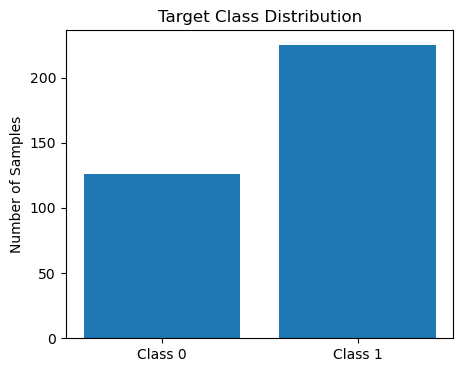

Class counts: {0: 126, 1: 225}


In [4]:
unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(5, 4))
plt.bar(unique, counts)
plt.xticks(unique, ["Class 0", "Class 1"])
plt.ylabel("Number of Samples")
plt.title("Target Class Distribution")
plt.show()

print("Class counts:", dict(zip(unique, counts)))


### Feature Scale Comparison

Many real datasets contain features measured on very different scales.
That can affect gradient-based learning, so we look at a simple summary
of the first several predictors before standardization.


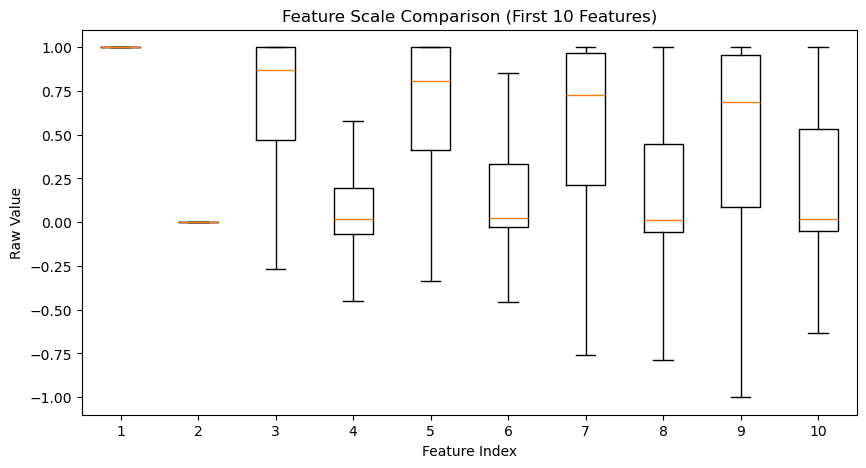

In [5]:
plt.figure(figsize=(10, 5))
plt.boxplot(X[:, :10], showfliers=False)
plt.title("Feature Scale Comparison (First 10 Features)")
plt.xlabel("Feature Index")
plt.ylabel("Raw Value")
plt.show()


### Standardization and Train-Test Split

We now standardize the predictors and split the data into training and
test sets using an 80/20 split.


In [6]:
X_std = standardize(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_std, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)


Training shape: (281, 34)
Test shape: (70, 34)


## Baseline Model: Perceptron

Before training the multilayer network, we first fit a simple
single-layer perceptron. This gives us a baseline so we can see whether
the hidden layer improves predictive performance.


In [8]:
perc = Perceptron(
    learning_rate=0.1,
    n_iterations=1000,
    random_state=42
)

perc.fit(X_train, y_train)
y_pred_perc = perc.predict(X_test)
perc_acc = accuracy_score(y_test, y_pred_perc)

print("Perceptron Accuracy:", perc_acc)


Perceptron Accuracy: 0.8142857142857143


## Training the Multilayer Perceptron

Next, we train an MLP with one hidden layer. The hidden layer lets the
model learn nonlinear interactions among the predictors.

Training uses:

- backpropagation
- gradient descent
- a sigmoid output layer for binary classification


In [10]:
mlp = MultilayerPerceptron(
    n_hidden=16,
    learning_rate=0.01,
    n_iterations=3000,
    random_state=42
)

mlp.fit(X_train, y_train)


Iteration 1000, Loss: 0.476292
Iteration 2000, Loss: 0.372104
Iteration 3000, Loss: 0.315869


## Model Evaluation

We measure performance with classification accuracy:

$$
\mathrm{Accuracy}
=
\frac{1}{n}\sum_{i=1}^{n}\mathbf{1}[\hat{y}_i = y_i]
$$

This is a simple and direct way to compare the perceptron and the MLP on
the same test set.


In [11]:
y_pred_mlp = mlp.predict(X_test)
mlp_acc = accuracy_score(y_test, y_pred_mlp)

print("MLP Accuracy:", mlp_acc)


MLP Accuracy: 0.8428571428571429


### Accuracy Comparison

A side-by-side comparison makes it easier to see the gain from adding
the hidden layer.


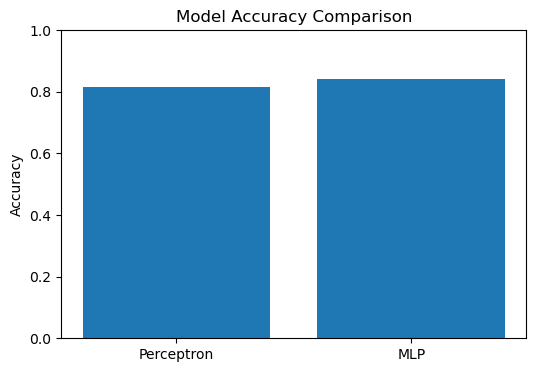

In [12]:
models = ["Perceptron", "MLP"]
scores = [perc_acc, mlp_acc]

plt.figure(figsize=(6, 4))
plt.bar(models, scores)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


## PCA Visualization of Test-Set Predictions

To get a rough visual summary, we project the standardized test data to
two dimensions using PCA. Then we mark which test observations were
classified correctly and incorrectly by the MLP.


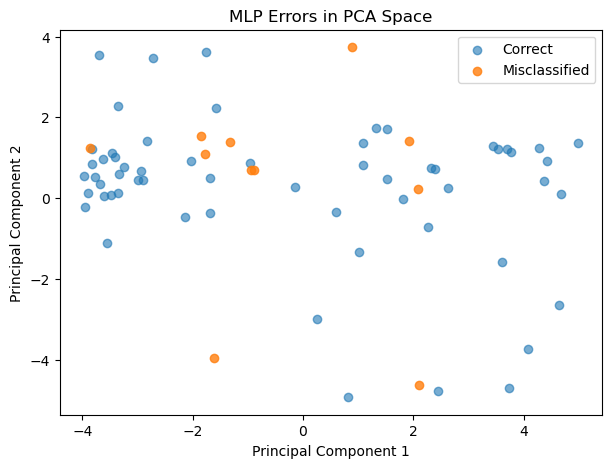

In [13]:
pca = PCA(n_components=2)
pca.fit(X_train)

X_test_2d = pca.transform(X_test)

errors = y_pred_mlp != y_test

plt.figure(figsize=(7, 5))
plt.scatter(
    X_test_2d[~errors, 0],
    X_test_2d[~errors, 1],
    label="Correct",
    alpha=0.6
)
plt.scatter(
    X_test_2d[errors, 0],
    X_test_2d[errors, 1],
    label="Misclassified",
    alpha=0.8
)
plt.legend()
plt.title("MLP Errors in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


### PCA Interpretation

The PCA view usually shows that the classes still overlap in two
dimensions. Even though the MLP is more flexible than the basic
perceptron, the overlap in the data limits how close we can get to
perfect classification.


## Conclusion

### Results Summary

| Model | Test Accuracy | Notes |
|---|---|---|
| Perceptron (single layer) | 81.43% | linear baseline, 1000 iterations |
| Multilayer Perceptron | 84.29% | one hidden layer, 16 units, 3000 iterations |
| **Improvement from hidden layer** | **+2.86 pp** | ~2 additional correct predictions out of 70 |

### Key Findings

- **The MLP outperforms the single-layer Perceptron, but the margin is modest** — 84.29% vs 81.43% on the test set. On 70 test samples, that's roughly 59 correct vs 57 correct, a difference of 2 observations. The hidden layer helps, but the ionosphere dataset isn't a dramatic showcase for nonlinearity — much of the signal is already linearly recoverable.

- **Training loss is still decreasing at iteration 3000** (0.476 → 0.372 → 0.316), which suggests the MLP has **not fully converged**. Running for more iterations, increasing the learning rate, or using a larger hidden layer could plausibly close more of the remaining error.

- **The hidden layer with sigmoid activation does what the math predicts**: it learns nonlinear feature interactions the perceptron cannot. The PCA error plot shows that misclassified points sit primarily in the region where the two classes overlap — these are likely genuinely hard cases rather than failures of model expressiveness.

- **Class imbalance (126 negative vs 225 positive) is mild but real** — the majority class accounts for 64% of the data, so a trivial "always predict positive" classifier would already reach ~64%. Both models clearly learn meaningful structure beyond this baseline, but accuracy alone doesn't fully capture the imbalance — precision, recall, and F1 by class would be a more informative next step.

### Limitations of This MLP

- **One hidden layer only** — the current `MultilayerPerceptron` implementation in `rice_ml` supports a single hidden layer. Deeper networks (e.g., two or three hidden layers) could potentially capture more complex patterns, but they're not available with this class as written.

- **Sigmoid activations everywhere** — modern deep nets use ReLU in hidden layers because sigmoid suffers from vanishing gradients, especially as networks get deeper. With only one hidden layer this isn't a serious problem, but it would limit any extension to deeper architectures.

- **No regularization** — the MLP has no L2 weight decay or dropout, so on smaller datasets it could memorize training noise. The fact that the training loss is still falling without obvious overfit signals is partly because 281 training samples × 34 features × 16 hidden units is a fairly low-capacity problem.

- **Not fully converged** — as noted above, the loss curve hasn't flattened. Reported numbers would likely improve with more iterations or hyperparameter tuning. A reader should treat 84.29% as a lower bound on what this architecture can reach, not a fixed performance number.

### Takeaway

Adding a hidden layer with nonlinear activation moves accuracy from 81.4% to 84.3% on this dataset — a real improvement, though smaller than what's often advertised for "deep learning." The result is a useful illustration of why MLPs are a meaningful stepping stone beyond the single-layer perceptron, while also showing that the gain is data-dependent: not every problem rewards nonlinearity heavily, and a well-trained linear model can be surprisingly competitive.